In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Data/app_user_behavior_dataset.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'Data/app_user_behavior_dataset.csv'

In [4]:
df = pd.read_csv("../Data/app_user_behavior_dataset.csv")

In [5]:
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [6]:
import os

print(os.getcwd())

c:\Users\acer\Desktop\App_User_Behavior_Segmentation\notebooks


In [7]:
import os

print(os.listdir(".."))

['Data', 'images', 'model', 'notebooks']


In [8]:
import os

print(os.listdir("../Data"))

['app_user_behavior_dataset.csv']


In [9]:
import os

file_path = os.path.join("..", "Data", "app_user_behavior_dataset.csv")
print(file_path)
print(os.path.exists(file_path))

..\Data\app_user_behavior_dataset.csv
True


In [10]:
df.shape

(50000, 25)

In [11]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  str    
 3   country                        50000 non-null  str    
 4   device_type                    50000 non-null  str    
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null  int64  
 1

In [13]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
country                             0
device_type                         0
app_version                         0
sessions_per_week                   0
avg_session_duration_min            0
daily_active_minutes                0
feature_clicks_per_session          0
notifications_opened_per_week       0
in_app_search_count                 0
pages_viewed_per_session            0
crash_events_last_30_days           0
support_tickets_raised              0
days_since_last_login               0
subscription_type                   0
ads_clicked_last_30_days            0
content_downloads                   0
social_shares                       0
rating_given                     5022
churn_risk_score                    0
engagement_score                    0
account_age_days                    0
marketing_source                    0
dtype: int64

In [14]:
df["rating_given"] = df["rating_given"].fillna(df["rating_given"].median())

In [15]:
df.isnull().sum()

user_id                          0
age                              0
gender                           0
country                          0
device_type                      0
app_version                      0
sessions_per_week                0
avg_session_duration_min         0
daily_active_minutes             0
feature_clicks_per_session       0
notifications_opened_per_week    0
in_app_search_count              0
pages_viewed_per_session         0
crash_events_last_30_days        0
support_tickets_raised           0
days_since_last_login            0
subscription_type                0
ads_clicked_last_30_days         0
content_downloads                0
social_shares                    0
rating_given                     0
churn_risk_score                 0
engagement_score                 0
account_age_days                 0
marketing_source                 0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,50000.0,124999.500000,14433.901067,100000.00,112499.75,124999.500,137499.25,149999.00
age,50000.0,38.513040,12.094948,18.00,28.00,39.000,49.00,59.00
app_version,50000.0,1.476126,0.470158,1.00,1.10,1.200,2.00,2.10
sessions_per_week,50000.0,7.999680,2.829438,0.00,6.00,8.000,10.00,26.00
avg_session_duration_min,50000.0,13.149842,8.946944,0.06,6.57,11.240,17.57,91.40
daily_active_minutes,50000.0,45.164537,19.505118,5.00,31.65,45.210,58.44,129.13
feature_clicks_per_session,50000.0,12.013920,3.480289,1.00,10.00,12.000,14.00,28.00
notifications_opened_per_week,50000.0,4.996620,2.235180,0.00,3.00,5.000,6.00,16.00
in_app_search_count,50000.0,3.999060,1.997763,0.00,3.00,4.000,5.00,19.00
pages_viewed_per_session,50000.0,13.470760,6.343635,3.00,8.00,13.000,19.00,24.00


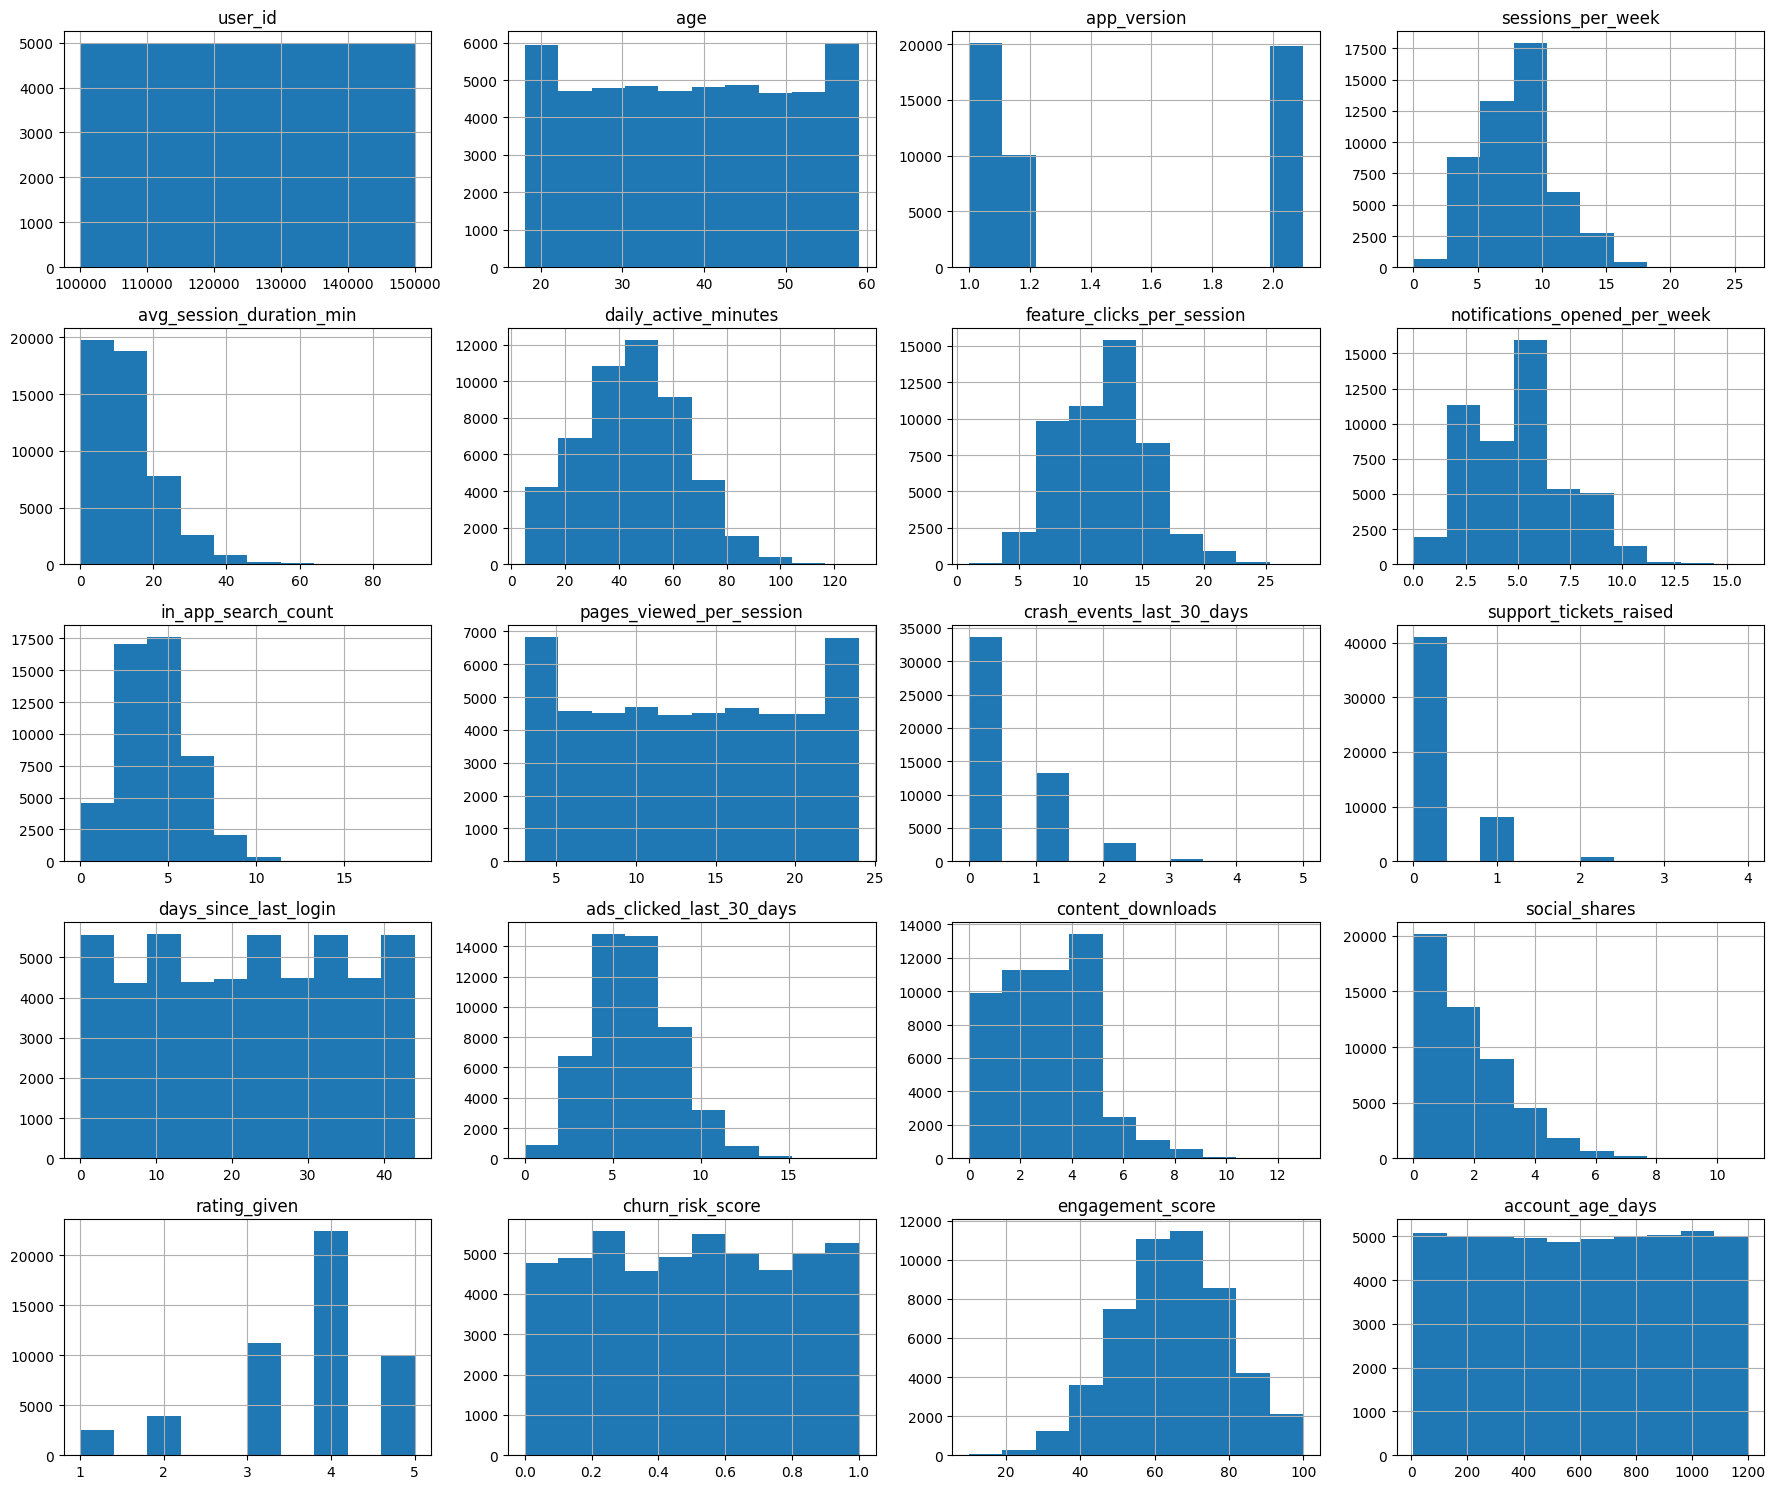

In [18]:
df.hist(figsize=(18,15))
plt.tight_layout()
plt.show()

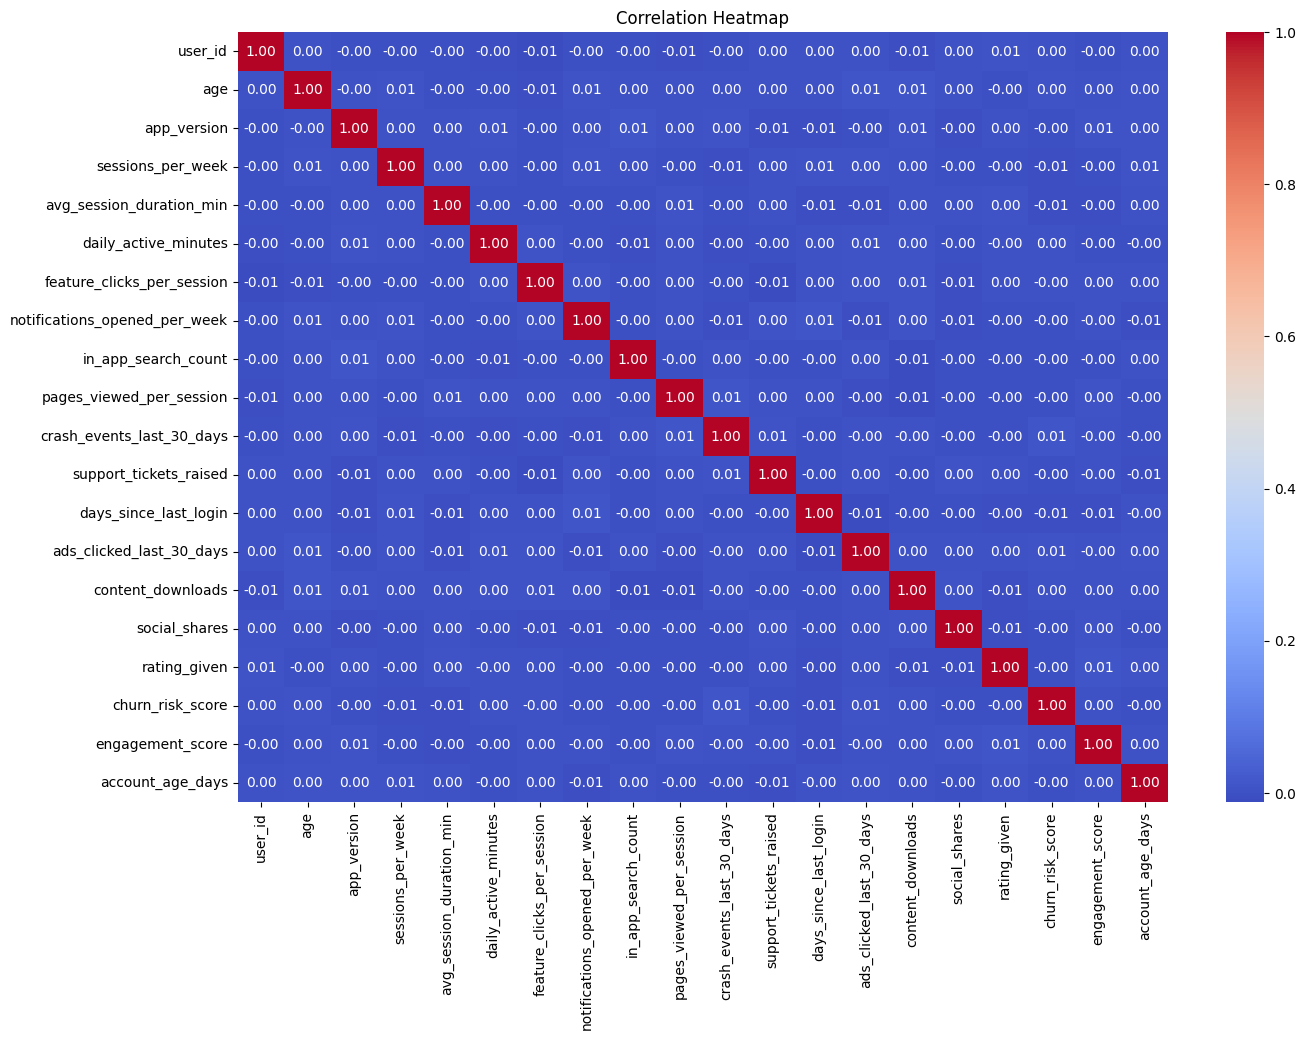

In [19]:
plt.figure(figsize=(15,10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

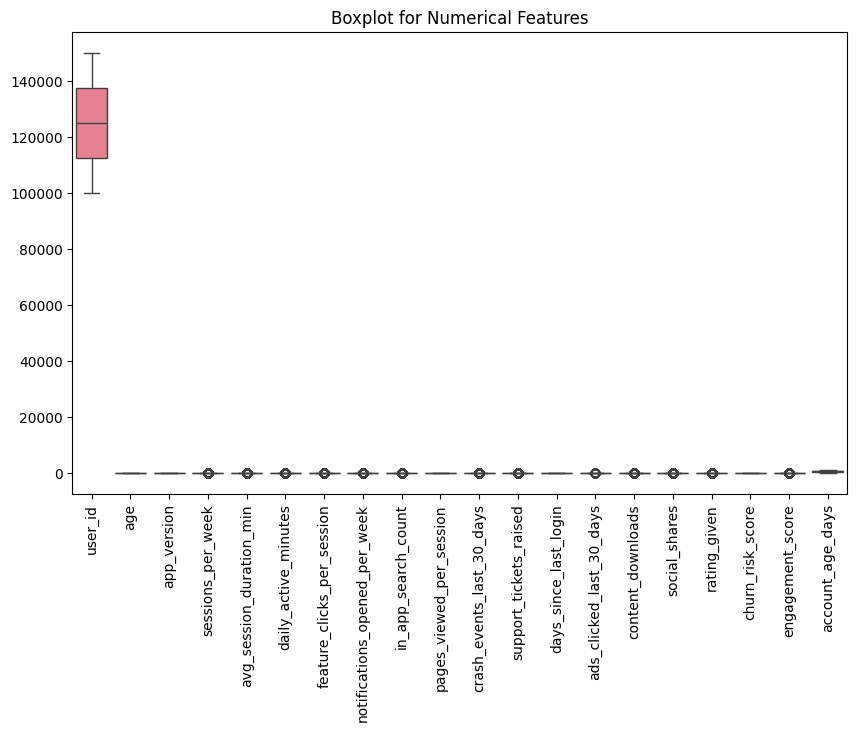

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title("Boxplot for Numerical Features")
plt.show()

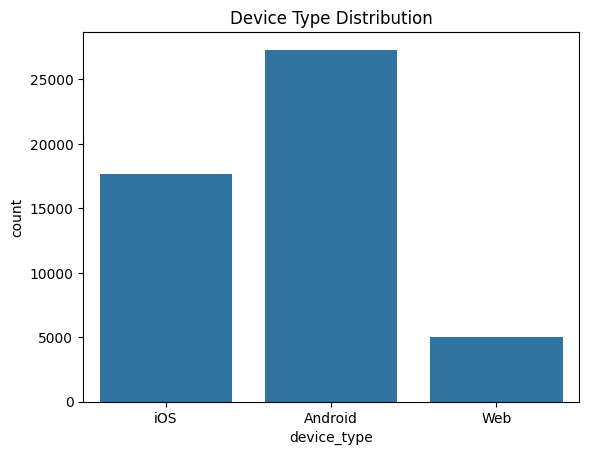

In [21]:
sns.countplot(x="device_type", data=df)
plt.title("Device Type Distribution")
plt.show()

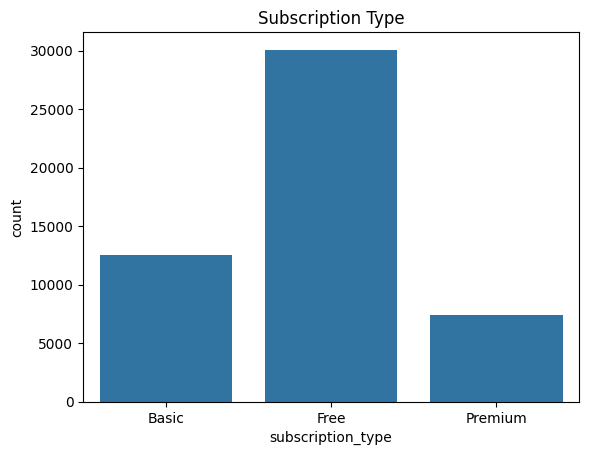

In [22]:
sns.countplot(x="subscription_type", data=df)
plt.title("Subscription Type")
plt.show()

In [24]:
df = df.drop("user_id", axis=1)

KeyError: "['user_id'] not found in axis"

In [25]:
df.columns

Index(['age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source'],
      dtype='str')

In [26]:
df.select_dtypes(include="object").columns

Index(['gender', 'country', 'device_type', 'subscription_type',
       'marketing_source'],
      dtype='str')

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,56,0,3,2,2.1,5,3.41,52.71,13,5,...,20,0,9,5,2,4.0,0.31,55.79,1152,4
1,46,1,5,2,1.0,8,24.44,42.03,7,7,...,7,1,8,3,3,3.0,0.87,82.39,1059,0
2,32,0,5,2,1.2,12,5.34,76.69,7,5,...,33,1,11,6,1,2.0,0.63,42.49,678,2
3,25,1,3,0,2.0,5,3.98,65.38,16,8,...,17,0,6,3,1,3.0,0.43,62.81,92,3
4,38,1,0,0,1.0,10,12.85,57.06,13,7,...,21,0,4,4,2,5.0,0.43,38.21,772,0


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  int64  
 1   gender                         50000 non-null  int64  
 2   country                        50000 non-null  int64  
 3   device_type                    50000 non-null  int64  
 4   app_version                    50000 non-null  float64
 5   sessions_per_week              50000 non-null  int64  
 6   avg_session_duration_min       50000 non-null  float64
 7   daily_active_minutes           50000 non-null  float64
 8   feature_clicks_per_session     50000 non-null  int64  
 9   notifications_opened_per_week  50000 non-null  int64  
 10  in_app_search_count            50000 non-null  int64  
 11  pages_viewed_per_session       50000 non-null  int64  
 12  crash_events_last_30_days      50000 non-null  int64  
 1

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [30]:
X_scaled

array([[ 1.44582147, -0.97894251, -0.21275324, ..., -0.61665925,
         1.58643491,  1.42857679],
       [ 0.61902169,  0.76443709,  0.9484368 , ...,  1.17595317,
         1.3173097 , -1.93959596],
       [-0.53849801, -0.97894251,  0.9484368 , ..., -1.51296546,
         0.21476452, -0.25550959],
       ...,
       [ 0.37098176,  0.76443709, -0.21275324, ...,  0.32075574,
         1.49383269, -0.25550959],
       [ 0.2056218 ,  0.76443709, -0.21275324, ...,  0.40836462,
         1.65299275, -0.25550959],
       [-1.03457788, -0.97894251,  0.36784178, ...,  0.87673516,
        -1.6980501 , -1.09755277]], shape=(50000, 24))

In [31]:
X_scaled.shape

(50000, 24)

In [34]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

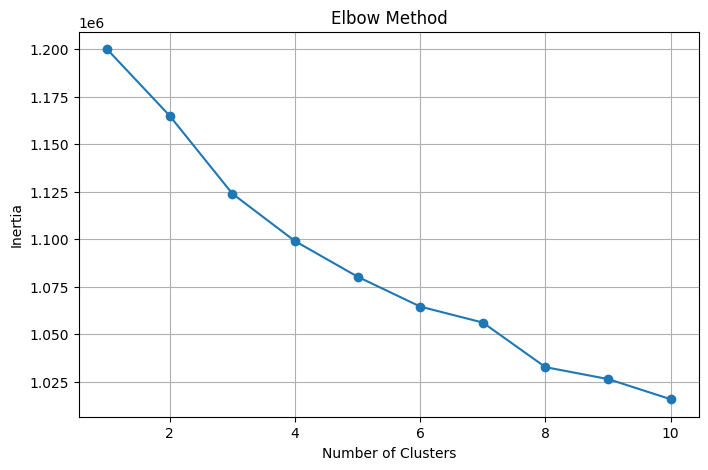

In [33]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [35]:
kmeans = KMeans(n_clusters=4, random_state=42)

In [36]:
clusters = kmeans.fit_predict(X_scaled)

In [37]:
df["Cluster"] = clusters

In [38]:
df.head()

,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,...,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source,Cluster
0,56,0,3,2,2.1,5,3.41,52.71,13,5,...,0,9,5,2,4.0,0.31,55.79,1152,4,0
1,46,1,5,2,1.0,8,24.44,42.03,7,7,...,1,8,3,3,3.0,0.87,82.39,1059,0,0
2,32,0,5,2,1.2,12,5.34,76.69,7,5,...,1,11,6,1,2.0,0.63,42.49,678,2,0
3,25,1,3,0,2.0,5,3.98,65.38,16,8,...,0,6,3,1,3.0,0.43,62.81,92,3,1
4,38,1,0,0,1.0,10,12.85,57.06,13,7,...,0,4,4,2,5.0,0.43,38.21,772,0,3


In [39]:
df["Cluster"].value_counts()

Cluster
0    15275
1    14770
3    11045
2     8910
Name: count, dtype: int64

In [40]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [41]:
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-1.219863,-0.500225,0
1,-1.759438,1.514302,0
2,-0.141533,2.313554,0
3,0.142893,-0.736456,1
4,0.618969,0.041859,3


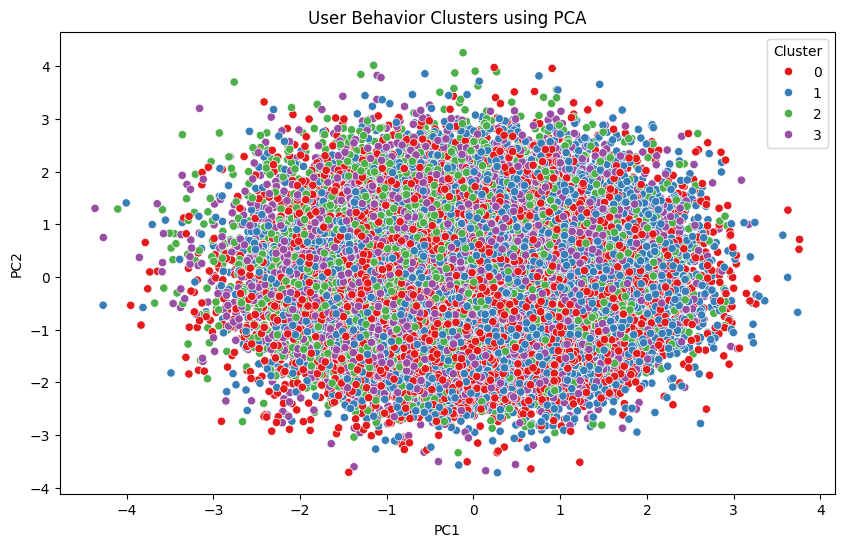

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("User Behavior Clusters using PCA")
plt.show()

In [43]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)
cluster_profile

,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
Cluster,,,,,,,,,,,,,,,,,,,,,
0,38.685172,0.563732,3.355417,1.947692,1.481303,8.009296,13.167374,45.038627,12.000786,4.980687,...,22.070180,0.907692,5.969100,3.003993,2.001637,3.678560,0.501707,64.890205,603.787627,2.309133
1,39.028707,0.586865,3.352133,0.135613,1.504502,8.094245,13.604754,45.025571,11.900000,4.985647,...,22.252268,0.911104,6.017874,2.933311,1.951523,3.664861,0.484702,64.286529,611.397089,3.163710
2,38.488103,0.568687,3.362738,0.810213,1.468541,8.013692,13.199873,45.038607,11.955107,5.014029,...,21.993378,0.905051,6.009764,2.990797,2.011448,3.669360,0.500272,64.911563,600.287318,2.295847
3,37.605523,0.518787,3.403803,0.124400,1.437139,7.848619,12.476902,45.626087,12.231870,5.019285,...,21.744047,0.863377,5.991942,3.101313,2.059846,3.655410,0.521654,65.907514,596.424083,1.151290


In [44]:
df.groupby("Cluster").size()

Cluster
0    15275
1    14770
2     8910
3    11045
dtype: int64

In [45]:
cluster_names = {
    0: "High Engagement",
    1: "Moderate Engagement",
    2: "Low Engagement",
    3: "Occasional Users"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

df[["Cluster", "Cluster_Name"]].head()

,Cluster,Cluster_Name
0,0,High Engagement
1,0,High Engagement
2,0,High Engagement
3,1,Moderate Engagement
4,3,Occasional Users


Business Insights
High Engagement Users
Highly active users.
Offer loyalty rewards and premium features.
Retain these users with exclusive benefits.
Moderate Engagement Users
Regular users with average engagement.
Improve engagement through personalized recommendations.
Low Engagement Users
At risk of becoming inactive.
Send reminders, discounts, and retention campaigns.
Occasional Users
Use the app infrequently.
Improve onboarding and send re-engagement notifications.


In [46]:
import joblib

joblib.dump(kmeans, "../model/kmeans.pkl")
joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(pca, "../model/pca.pkl")

['../model/pca.pkl']

In [47]:
import os

print(os.listdir("../model"))

['kmeans.pkl', 'pca.pkl', 'scaler.pkl']
